In [45]:
# utils
import os 
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
# torch
import torch
import glob
from pathlib import Path
import torch.optim as optim
from torchinfo import summary
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models, datasets

#Remove Warnings
import warnings
warnings.filterwarnings('ignore')

In [76]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [47]:
train_dir = r"D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Training"
test_dir = r"D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Testing"
train_dir,test_dir

('D:\\Users\\DEBJIT DAS\\brain-tumor-detection-using-mri\\brain\\Training',
 'D:\\Users\\DEBJIT DAS\\brain-tumor-detection-using-mri\\brain\\Testing')

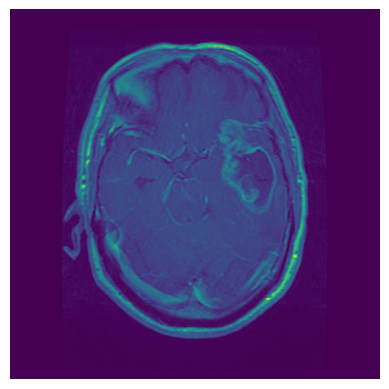

In [48]:
image = Image.open(r"D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Testing\glioma\Te-gl_6.jpg")
plt.imshow(image)
plt.axis("off")
plt.show()

In [49]:
categories = os.listdir(train_dir)
print(categories)

['glioma', 'meningioma', 'notumor', 'pituitary']


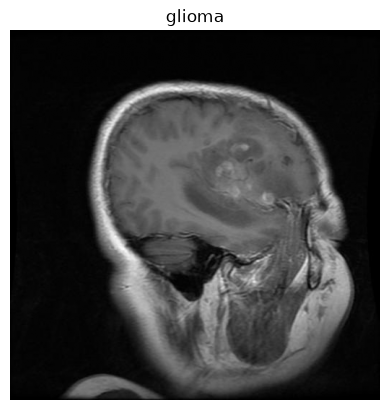

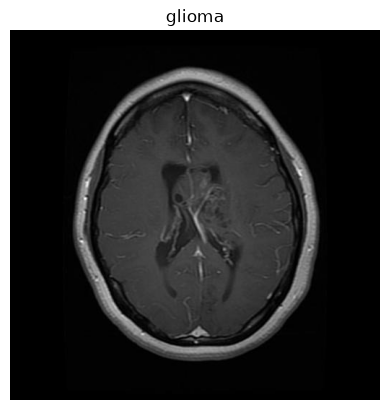

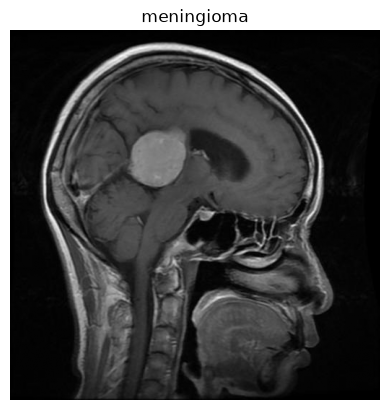

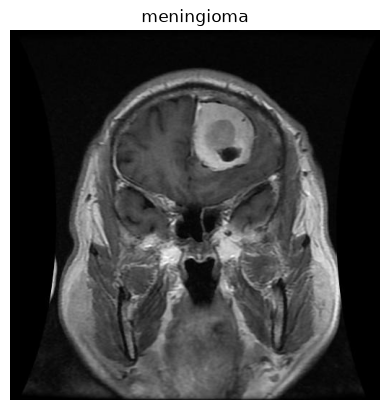

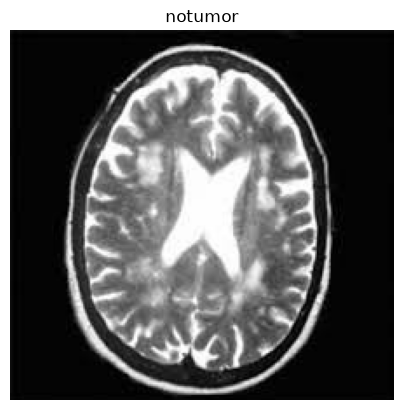

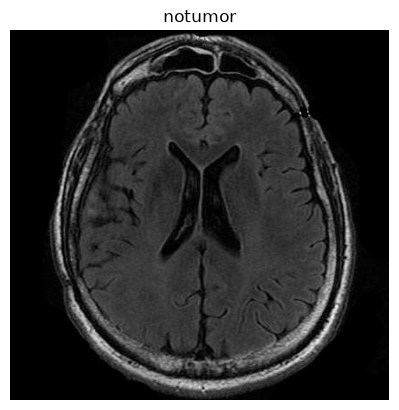

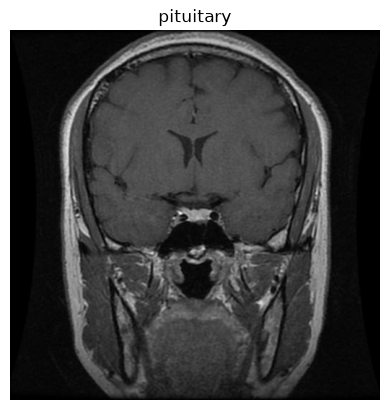

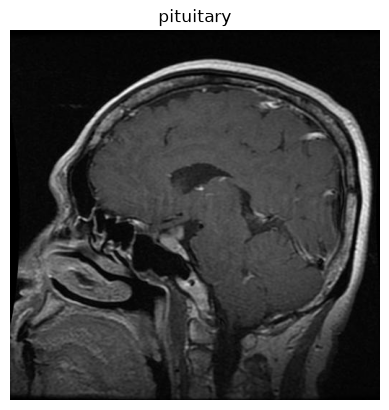

In [50]:


categories = os.listdir(train_dir)

for category in categories:
    folder = os.path.join(train_dir, category)

    images = random.sample(os.listdir(folder), 2)

    for image_name in images:
        image = Image.open(os.path.join(folder, image_name))

        plt.imshow(image, cmap="gray")
        plt.title(category)
        plt.axis("off")
        plt.show()

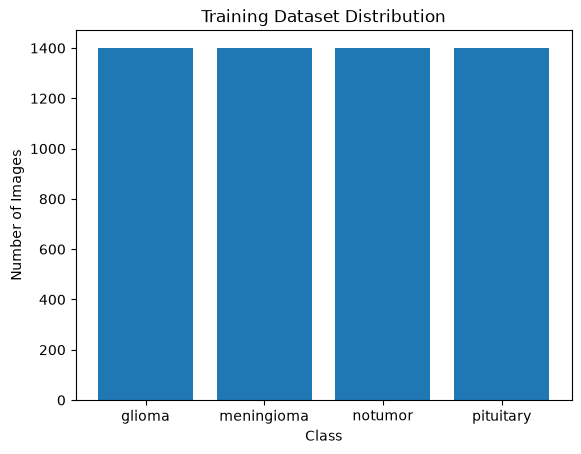

In [51]:
import os
import matplotlib.pyplot as plt

def plot_distribution():
    counts = []

    for category in categories:
        folder = os.path.join(train_dir, category)
        count = len(os.listdir(folder))
        counts.append(count)

    plt.bar(categories, counts)
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.title("Training Dataset Distribution")
    plt.show()

plot_distribution()

In [52]:
for category in categories:
    folder = os.path.join(train_dir, category)
    print(category, ":", len(os.listdir(folder)))

glioma : 1400
meningioma : 1400
notumor : 1400
pituitary : 1400


Image path : D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Training\pituitary\Tr-pi_673.jpg
Image Class : pituitary
Image Height : 512
Image Width : 512


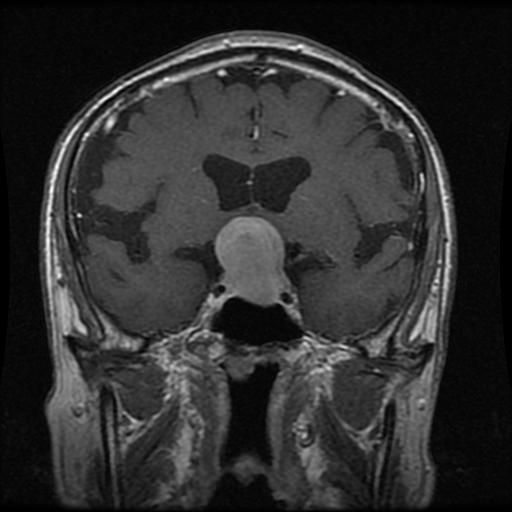

In [53]:
random.seed(42)
image_path_list = glob.glob(
    r'D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Training\*/*.jpg'
    
)
random_image_path = random.choice(image_path_list)
image_class = Path(random_image_path).parent.stem



img = Image.open(random_image_path)
print(f"Image path : {random_image_path}")
print(f"Image Class : {image_class}")
print(f"Image Height : {img.height}")
print(f"Image Width : {img.width}")
img


In [54]:
image_width = 128
image_height = 128

image_size = (image_width,image_height)

transform_images = transforms.Compose([
    transforms.Resize(size=image_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

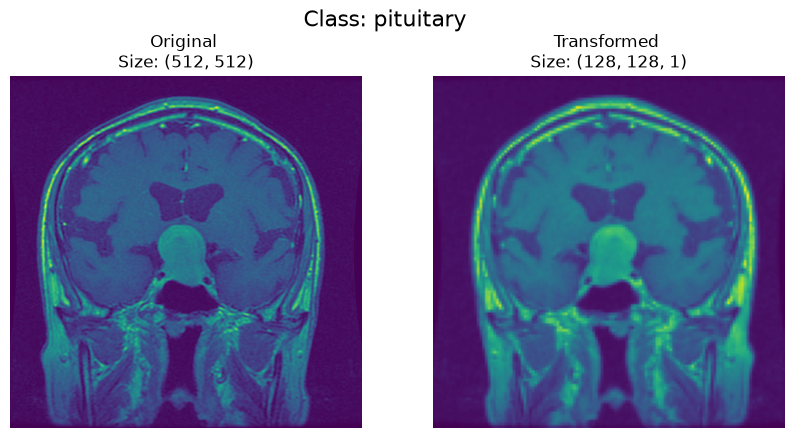

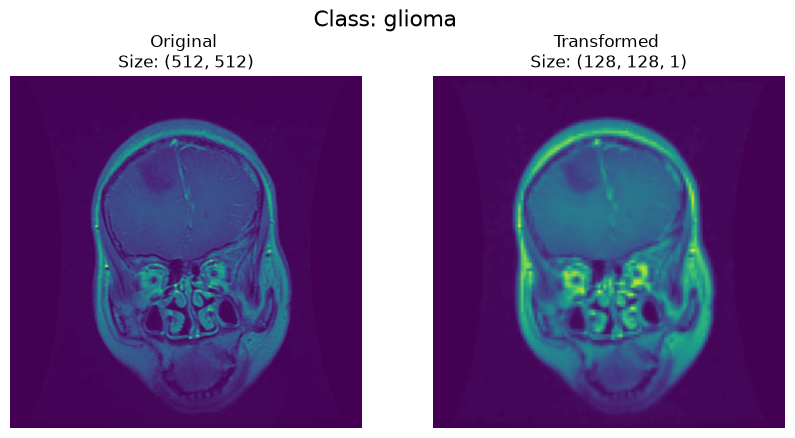

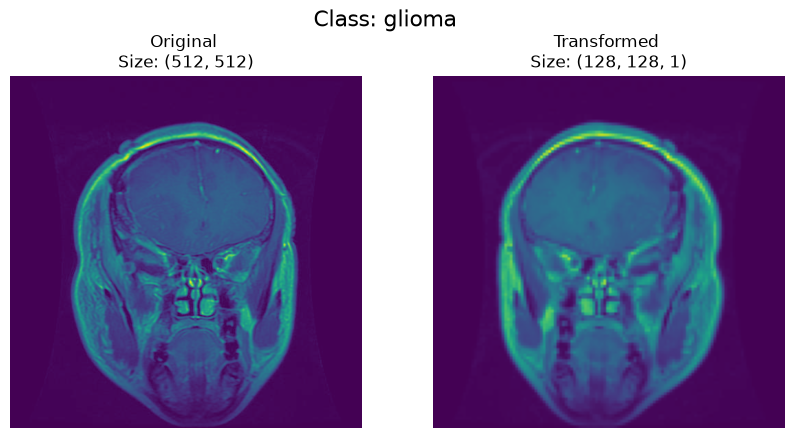

In [55]:

def transform_all_images(image_paths, transform, n=3,seed = 42):
    random.seed(42)
    sampled_paths = random.sample(image_paths, k=min(n, len(image_paths)))
    for img_path in sampled_paths:
        with Image.open(img_path) as f:
            fig, ax = plt.subplots(1, 2, figsize=(10, 5))
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            transformed = transform(f)  
            transformed = transformed.permute(1, 2, 0).numpy()  
            ax[1].imshow(transformed)
            ax[1].set_title(f"Transformed \nSize: {transformed.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {Path(img_path).parent.stem}", fontsize=16)
            plt.show()

transform_all_images(image_path_list, transform=transform_images, n=3)

In [56]:
train_data = datasets.ImageFolder(root=train_dir, transform=transform_images,target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=transform_images)
print(f"Train Data {train_data}\n Test Data {test_data}")

Train Data Dataset ImageFolder
    Number of datapoints: 5600
    Root location: D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Training
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
 Test Data Dataset ImageFolder
    Number of datapoints: 1600
    Root location: D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Testing
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [57]:
print(f"Class name : {train_data.classes}")
print(f"Class name : {train_data.class_to_idx}")
print(f"The Lenght of Traning and Test Data Set  :",len(train_data),len(test_data))

Class name : ['glioma', 'meningioma', 'notumor', 'pituitary']
Class name : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
The Lenght of Traning and Test Data Set  : 5600 1600


In [58]:
img, label = train_data[0]
print(f"Image Tensor: {img}")
print(f"Image Shape: {img.shape}")
print(f"Image DataType: {img.dtype}")
print(f"Image label: {label}")
print(f" Label datatype : {label}")

Image Tensor: tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])
Image Shape: torch.Size([3, 128, 128])
Image DataType: torch.float32
Image label: 0
 Label datatype : 0


In [59]:
num_of_workers = os.cpu_count()
train_loader = DataLoader(train_data,batch_size=32,shuffle=True,num_workers=num_of_workers)
test_loader = DataLoader(test_data,batch_size=32,shuffle=False,num_workers=num_of_workers)
train_loader,test_loader

(<torch.utils.data.dataloader.DataLoader at 0x1fd8060acd0>,
 <torch.utils.data.dataloader.DataLoader at 0x1fdfaeabb90>)

In [60]:
img, label = next(iter(train_loader))
print(f"Image shape {img.shape}")
print(f"Label shape: {label}")

Image shape torch.Size([32, 3, 128, 128])
Label shape: tensor([2, 0, 2, 3, 2, 3, 2, 2, 3, 3, 3, 2, 1, 0, 2, 1, 0, 1, 0, 3, 1, 3, 2, 0,
        2, 2, 3, 3, 1, 0, 2, 1])


In [61]:
image_height = 224
image_width = 224 
image_size = (image_height,image_width) 

train_augmentation = transforms.Compose(
    [
       transforms.Resize(size= image_size),
       transforms.TrivialAugmentWide(),
       transforms.ToTensor() 
    ]
)
test_augmentation = transforms.Compose(
    [
       transforms.Resize(size= image_size),
       transforms.ToTensor() 
    ]
)

In [62]:
train_data_augmentation = datasets.ImageFolder(train_dir,transform=train_augmentation)
test_data_augmentation = datasets.ImageFolder(test_dir,transform=test_augmentation)

In [63]:
torch.manual_seed(42)

In [64]:
image_width = 128
image_height = 128

image_size = (image_width,image_height)

transform_images = transforms.Compose([
    transforms.Resize(size=image_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [65]:
train_augmented_loader = DataLoader(train_data_augmentation,batch_size=32,shuffle=True,num_workers=num_of_workers,pin_memory=True)
test_augmented_loader = DataLoader(test_data_augmentation,batch_size=32,shuffle=False,num_workers=num_of_workers,pin_memory=True)
train_augmented_loader,test_augmented_loader

(<torch.utils.data.dataloader.DataLoader at 0x1fdfe272690>,
 <torch.utils.data.dataloader.DataLoader at 0x1fd806a4590>)

In [66]:
class ImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        
        self.conv_layer_1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.4)
        )

        
        self.conv_layer_2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.4)

        )

       
        self.conv_layer_3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.4)

        )

        
        self.conv_layer_4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.4)

        )

        
        self.conv_layer_5 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 2)  
        )

    def forward(self, x):
        x = self.conv_layer_1(x)
        x = self.conv_layer_2(x)
        x = self.conv_layer_3(x)
        x = self.conv_layer_4(x)
        x = self.conv_layer_5(x)

        x = self.classifier(x)

        return x


model = ImageClassifier().to(device)

In [70]:
def train_step(model,dataloader,loss_fn,optimizer):
    
    model.train()
    
    total_loss = 0
    total_image = 0
    total_correct = 0
    
    for images, labels in dataloader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        prediction = model(images)
        
        loss = loss_fn(prediction,labels)
        
        optimizer.zero_grad()
        
        loss.backward()
        
        optimizer.step()
        
        total_loss += loss.item()
        
        predicted_labels = prediction.argmax(dim = 1)
        
        total_correct += (predicted_labels == labels).sum().item()
        
        total_image += labels.size(0)
        
    avg_loss = total_loss/ len(dataloader)
    
    accuracy = total_correct/total_image
    
    return avg_loss, accuracy       

In [71]:
def test_step(model, dataloader, loss_fn):

    model.eval()

    total_loss = 0
    total_correct = 0
    total_images = 0

    with torch.inference_mode():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            predictions = model(images)

            loss = loss_fn(predictions, labels)

            total_loss += loss.item()

            predicted_labels = predictions.argmax(dim=1)

            total_correct += (predicted_labels == labels).sum().item()

            total_images += labels.size(0)

    average_loss = total_loss / len(dataloader)
    accuracy = total_correct / total_images

    return average_loss, accuracy

In [72]:
def train(model,train_loader,test_loader,loss_fn,optimizer,epochs):
    results = {
        "train_loss":[],
        "train_acc":[],
        "test_loss":[],
        "test_acc":[]
    }
    
    for epoch in tqdm(range(epochs)):
        train_loss ,train_acc = train_step(model,train_loader,loss_fn,optimizer)
        test_loss ,test_acc = test_step(model,test_loader,loss_fn)
        
        
        print(f"\n Epoch  {epoch + 1}/{epochs}")
        
        print(f"Train_loss: {train_loss:.4f} " )
        print(f"Train_acc: {train_acc:.4f} " )
        print(f"Test_loss: {test_loss:.4f}  " )
        print(f"Test_acc: {test_acc:.4f}  " )
        
        
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        
    return results
    
        

In [73]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
num_epochs = 25 
learning_rate = 1e-3
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.parameters(),lr=learning_rate )

In [ ]:
from tqdm.auto import tqdm
from timeit import default_timer as timer
start_time = timer()

num_classes = len(train_data_augmentation.classes)
model.classifier[-1] = nn.Linear(
    model.classifier[-1].in_features, num_classes
).to(device)

# Recreate the optimizer so it includes the new output layer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

model_result = train(
    model=model,
    train_loader=train_augmented_loader,
    test_loader=test_augmented_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=num_epochs
)

end_time = timer()


print(f"\nTraining Time : {end_time-start_time:.2f} seconds")

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
